# Thesis Experiment: RL-Based Gamma Controller (Weekly Rebalancing)
**Setup:** 7-Day Rebalancing Frequency for realistic portfolio management.

---

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns
import warnings
import os
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from scipy.optimize import minimize
from scipy.optimize import minimize

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print("Libraries loaded.")

Libraries loaded.


## Phase 1: Data Preparation

In [12]:
file_old = 'crypto_data_real.xlsx'
file_2024 = 'crypto_data_2024.xlsx'

def load_and_preprocess(f1, f2):
    r_old = pd.read_excel(f1, sheet_name='Returns', index_col=0)
    r_2024 = pd.read_excel(f2, sheet_name='Returns', index_col=0)
    r_old.index = pd.to_datetime(r_old.index)
    r_2024.index = pd.to_datetime(r_2024.index)
    assets = list(set(r_old.columns) & set(r_2024.columns))
    assets.sort()
    return r_old[assets], r_2024[assets], assets

ret_old, ret_2024, assets = load_and_preprocess(file_old, file_2024)

# Global Settings for Backtesting
SET_WINDOW = 30
SET_REBALANCE = 7
print(f"Data loaded. Assets: {len(assets)}")

Data loaded. Assets: 10


## Phase 2: Core Functions

In [13]:
def apply_rmt_filter(returns_window):
    T, N = returns_window.shape
    corr_mat = returns_window.corr().fillna(0).values
    eigenvalues, eigenvectors = np.linalg.eigh(corr_mat)
    Q = T / N
    lambda_max = (1 + np.sqrt(1/Q))**2
    
    # Filter: Set non-significant eigenvalues to 0 (RMT Standard)
    # Sesuai Giudici (2020), hanya deviating eigenvalues yang dipertahankan
    eigenvalues[eigenvalues < lambda_max] = 0
    
    # Reconstruction
    corr_denoised = eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T
    np.fill_diagonal(corr_denoised, 1)
    return corr_denoised

def get_centrality_weights(returns_window, gamma=1.0):
    """
    Computes Network-Regularized Markowitz weights as per Giudici et al (2020):
    1. RMT Filter
    2. MST Reduction (Langkah krusial paper)
    3. Eigenvector Centrality from MST structure
    4. Optimization: w' * Sigma * w + gamma * (centrality' * w)
    """
    T, N = returns_window.shape
    mu = returns_window.mean().values
    sigma = returns_window.std().values
    
    # 1. Denoised Covariance Matrix (RMT)
    corr_f = apply_rmt_filter(returns_window)
    cov_f = np.outer(sigma, sigma) * corr_f
    cov_f += np.eye(N) * 1e-8 # Numerical stability
    
    # 2. MST Reduction (Giudici Step)
    dist_mat = np.sqrt(np.maximum(0, 2 * (1 - corr_f)))
    G_full = nx.from_numpy_array(dist_mat)
    mst = nx.minimum_spanning_tree(G_full)
    
    # 3. Centrality calculation from MST
    try:
        centrality = nx.eigenvector_centrality(mst, max_iter=2000)
        cent_vec = np.array([centrality[i] for i in range(N)])
    except:
        cent_vec = np.array(list(nx.degree_centrality(mst).values()))

    # 4. Optimization
    fun = lambda w: w.T @ cov_f @ w + gamma * np.sum(cent_vec * w)
    
    # Constraint 1: bobot harus sum=1
    # Constraint 2: return portofolio >= rata-rata return (mencegah dominasi stablecoin)
    cons = (
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: np.dot(w, mu) - np.mean(mu)},
    )
    # Bound 0.1 as per paper for crypto portfolios
    bnds = tuple((0, 0.4) for _ in range(N))
    x0 = np.ones(N) / N
    
    res = minimize(fun, x0, method='SLSQP', bounds=bnds, constraints=cons)
    
    if not res.success:
        return np.ones(N) / N
        
    return res.x

def get_network_metrics(returns_window):
    """
    Ekstraksi fitur murni dari struktur jaringan (Graph-based features).
    """
    T, N = returns_window.shape
    # 1. RMT Filter & Density
    corr_f = apply_rmt_filter(returns_window)
    # Network Density: Kepadatan korelasi signifikan (>0.1) setelah denoising
    density = np.sum(np.abs(corr_f) > 0.1) / (N * N)
    
    # 2. MST & Distance
    dist_mat = np.sqrt(np.maximum(0, 2 * (1 - corr_f)))
    G_full = nx.from_numpy_array(dist_mat)
    mst = nx.minimum_spanning_tree(G_full)
    mst_dist = sum([d['weight'] for u, v, d in mst.edges(data=True)]) # Total bobot MST
    
    # 3. Centrality Metrics dari MST
    try:
        centrality = nx.eigenvector_centrality(mst, max_iter=2000)
        cent_vec = np.array([centrality[i] for i in range(N)])
    except:
        cent_vec = np.array(list(nx.degree_centrality(mst).values()))
        
    st_c = np.std(cent_vec)
    mean_c = np.mean(cent_vec)
    max_c = np.max(cent_vec)
    
    return np.array([
        st_c * 10,      # 1. Dispersion of Centrality
        mean_c * 10,    # 2. Mean Centrality
        mst_dist * 0.1, # 3. MST Total Distance
        max_c,          # 4. Max Centrality
        density         # 5. Network Density
    ], dtype=np.float32)

def calculate_metrics(returns_series):
    """Hitung metrik performa portofolio standar."""
    total_ret = (1 + returns_series).prod() - 1
    ann_ret = (1 + total_ret) ** (252 / len(returns_series)) - 1
    ann_vol = returns_series.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    cumulative = (1 + returns_series).cumprod()
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak
    max_dd = drawdown.min()
    return {
        'Total Return': total_ret,
        'Ann. Return': ann_ret,
        'Ann. Volatility': ann_vol,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': max_dd,
    }

class PortfolioStrategy:
    def __init__(self, name): 
        self.name = name
        self.last_gamma = 1.0
    def compute_weights(self, returns_window): raise NotImplementedError()
    
class EquallyWeighted(PortfolioStrategy):
    def compute_weights(self, returns_window): return np.ones(returns_window.shape[1])/returns_window.shape[1]
class ClassicalMarkowitz(PortfolioStrategy):
    def compute_weights(self, returns_window):
        cov = returns_window.cov().values
        inv_cov = np.linalg.pinv(cov)
        w = np.clip(inv_cov @ np.ones(cov.shape[0]), 0, 1)
        return w / np.sum(w)
class NetworkMarkowitz(PortfolioStrategy):
    def __init__(self, name, gamma=1.0):
        super().__init__(name)
        self.gamma = gamma
    def compute_weights(self, returns_window): return get_centrality_weights(returns_window, self.gamma)

## Phase 3: RL Agent

In [14]:
class GammaPortfolioEnv(gym.Env):
    def __init__(self, returns_data, window_size=30, reward_mode='sharpe'):
        super().__init__()
        self.data = returns_data
        self.window_size = window_size
        self.reward_mode = reward_mode
        self.current_step = window_size
        self.action_space = spaces.Box(low=-5.0, high=5.0, shape=(1,), dtype=np.float32)
        # 5 NW features + 4 market features = 9 features
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(9,), dtype=np.float32)
        self.port_val = 1.0
        self.peak_val = 1.0
        
    def _get_obs(self):
        win = self.data.iloc[self.current_step - self.window_size : self.current_step]
        nw_features = get_network_metrics(win)
        
        # Fast-changing market features (berubah tiap hari)
        short_ret = win.iloc[-5:].mean().mean()    # 5-day avg return
        long_ret = win.mean().mean()                # full window avg return
        momentum = short_ret - long_ret             # momentum signal
        recent_vol = win.iloc[-5:].std().mean()     # 5-day volatility
        
        market_features = np.array([
            short_ret * 100,   # scale up
            momentum * 100,    # scale up
            recent_vol * 100,  # scale up
            self.port_val - 1  # current P&L
        ], dtype=np.float32)
        
        return np.concatenate([nw_features, market_features])
        
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = self.window_size
        self.port_val = 1.0
        self.peak_val = 1.0
        return self._get_obs(), {}
        
    def step(self, action):
        win = self.data.iloc[self.current_step - self.window_size : self.current_step]
        w = get_centrality_weights(win, float(action[0]))
        port_ret = np.dot(w, self.data.iloc[self.current_step].values)
        
        self.port_val *= (1 + port_ret)
        self.peak_val = max(self.peak_val, self.port_val)
        drawdown = (self.port_val - self.peak_val) / self.peak_val
        ew_ret = self.data.iloc[self.current_step].mean()
        
        # Semua reward di-scale ×100 agar PPO dapat sinyal yang cukup besar
        if self.reward_mode == 'raw_return':     reward = port_ret * 100
        elif self.reward_mode == 'excess_return': reward = (port_ret - ew_ret) * 100
        elif self.reward_mode == 'defensive':     reward = (port_ret - 2.0 * abs(drawdown)) * 100
        elif self.reward_mode == 'total_return':  reward = port_ret * 100
        else: reward = port_ret / (win.values.std() + 1e-6) * 10  # sharpe-like, scaled
            
        self.current_step += 1
        done = self.current_step >= len(self.data) - 1
        return self._get_obs(), reward, done, False, {}

class RLNetworkMarkowitz(PortfolioStrategy):
    """
    RL-based strategy. Supports gamma centering:
    - gamma_center=1.0, gamma_range=1.0 → action ∈ [-1,1] maps to gamma ∈ [0, 2]
    - gamma_center=0.0, gamma_range=5.0 → legacy mode: gamma ∈ [-5, 5]
    """
    def __init__(self, name, model_path, gamma_center=0.0, gamma_range=5.0):
        super().__init__(name)
        self.model = PPO.load(model_path)
        self.gamma_center = gamma_center
        self.gamma_range = gamma_range
    def compute_weights(self, returns_window):
        nw_features = get_network_metrics(returns_window)
        short_ret = returns_window.iloc[-5:].mean().mean()
        long_ret = returns_window.mean().mean()
        momentum = short_ret - long_ret
        recent_vol = returns_window.iloc[-5:].std().mean()
        market_features = np.array([
            short_ret * 100, momentum * 100, recent_vol * 100, 0.0
        ], dtype=np.float32)
        obs = np.concatenate([nw_features, market_features])
        obs = np.nan_to_num(obs)
        action, _ = self.model.predict(obs, deterministic=True)
        # Map action to gamma using centering
        self.last_gamma = self.gamma_center + float(action[0]) * self.gamma_range
        return get_centrality_weights(returns_window, gamma=self.last_gamma)

In [15]:
# ============================================================
# Fast Environment: Precompute all heavy computations ONCE
# ============================================================
# Bottleneck: setiap env.step() memanggil get_network_metrics() dan
# get_centrality_weights() yang masing-masing butuh RMT + MST + eigenvector.
# Solusi: precompute semua data per window position sebelum training.

def precompute_env_data(returns_data, window_size=30):
    """
    Precompute semua data yang dibutuhkan environment untuk setiap step.
    Returns:
        obs_cache: dict step_idx -> (nw_features, market_features)
        opt_cache: dict step_idx -> (cov_f, cent_vec, mu)
        baseline_ret_cache: dict step_idx -> NW(gamma=1.0) portfolio return
    """
    n_steps = len(returns_data) - window_size
    obs_cache = {}
    opt_cache = {}
    baseline_ret_cache = {}
    
    print(f"Precomputing {n_steps} window positions...")
    for i in range(window_size, len(returns_data)):
        win = returns_data.iloc[i - window_size : i]
        T, N = win.shape
        
        # === Network metrics (for observation) ===
        nw_features = get_network_metrics(win)
        
        # === Market features ===
        short_ret = win.iloc[-5:].mean().mean()
        long_ret = win.mean().mean()
        momentum = short_ret - long_ret
        recent_vol = win.iloc[-5:].std().mean()
        market_features = np.array([
            short_ret * 100, momentum * 100, recent_vol * 100, 0.0
        ], dtype=np.float32)
        
        obs_cache[i] = (nw_features, market_features)
        
        # === Intermediate matrices (for fast weight optimization) ===
        mu = win.mean().values
        sigma = win.std().values
        corr_f = apply_rmt_filter(win)
        cov_f = np.outer(sigma, sigma) * corr_f
        cov_f += np.eye(N) * 1e-8
        
        dist_mat = np.sqrt(np.maximum(0, 2 * (1 - corr_f)))
        G_full = nx.from_numpy_array(dist_mat)
        mst = nx.minimum_spanning_tree(G_full)
        try:
            centrality = nx.eigenvector_centrality(mst, max_iter=2000)
            cent_vec = np.array([centrality[j] for j in range(N)])
        except:
            cent_vec = np.array(list(nx.degree_centrality(mst).values()))
        
        opt_cache[i] = (cov_f, cent_vec, mu)
        
        # === Precompute NW baseline return (gamma=1.0) for excess reward ===
        w_baseline = fast_centrality_weights(cov_f, cent_vec, mu, gamma=1.0)
        baseline_ret_cache[i] = np.dot(w_baseline, returns_data.iloc[i].values)
    
    print(f"Precomputation done! ({n_steps} positions cached)")
    return obs_cache, opt_cache, baseline_ret_cache


def fast_centrality_weights(cov_f, cent_vec, mu, gamma):
    """Lightweight optimization using precomputed matrices."""
    N = len(mu)
    fun = lambda w: w.T @ cov_f @ w + gamma * np.sum(cent_vec * w)
    cons = (
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: np.dot(w, mu) - np.mean(mu)},
    )
    bnds = tuple((0, 0.4) for _ in range(N))
    x0 = np.ones(N) / N
    res = minimize(fun, x0, method='SLSQP', bounds=bnds, constraints=cons)
    if not res.success:
        return np.ones(N) / N
    return res.x


class GammaPortfolioEnvFast(gym.Env):
    """
    Fast precomputed environment with gamma centering.
    
    Key improvement: gamma_center parameter.
    - action ∈ [-1, 1] → gamma = gamma_center + action
    - Default gamma_center=1.0, so action=0 → gamma=1.0 (NW baseline)
    - RL hanya perlu belajar KAPAN dan SEBERAPA BESAR menyimpang dari baseline
    
    Reward modes:
    - 'excess_nw': reward = (port_ret - NW_baseline_ret) × 100
      → RL dipaksa belajar MENGALAHKAN NW(gamma=1.0)
    - 'defensive': reward = port_ret - 2×|drawdown|
    - 'total_return': reward = port_ret × 100
    """
    def __init__(self, returns_data, obs_cache, opt_cache,
                 baseline_ret_cache=None,
                 window_size=30, reward_mode='sharpe',
                 gamma_center=1.0, gamma_range=1.0):
        super().__init__()
        self.data = returns_data
        self.obs_cache = obs_cache
        self.opt_cache = opt_cache
        self.baseline_ret_cache = baseline_ret_cache or {}
        self.window_size = window_size
        self.reward_mode = reward_mode
        self.gamma_center = gamma_center
        self.gamma_range = gamma_range
        self.current_step = window_size
        # Action ∈ [-1, 1], mapped to gamma ∈ [center-range, center+range]
        self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(9,), dtype=np.float32)
        self.port_val = 1.0
        self.peak_val = 1.0
        
    def _action_to_gamma(self, action):
        return self.gamma_center + action * self.gamma_range
        
    def _get_obs(self):
        nw_features, market_features = self.obs_cache[self.current_step]
        mf = market_features.copy()
        mf[3] = self.port_val - 1
        return np.concatenate([nw_features, mf])
        
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = self.window_size
        self.port_val = 1.0
        self.peak_val = 1.0
        return self._get_obs(), {}
        
    def step(self, action):
        gamma = self._action_to_gamma(float(action[0]))
        cov_f, cent_vec, mu = self.opt_cache[self.current_step]
        w = fast_centrality_weights(cov_f, cent_vec, mu, gamma)
        port_ret = np.dot(w, self.data.iloc[self.current_step].values)
        
        self.port_val *= (1 + port_ret)
        self.peak_val = max(self.peak_val, self.port_val)
        drawdown = (self.port_val - self.peak_val) / self.peak_val
        ew_ret = self.data.iloc[self.current_step].mean()
        
        # Baseline NW return for excess reward
        nw_ret = self.baseline_ret_cache.get(self.current_step, ew_ret)
        
        if self.reward_mode == 'excess_nw':
            # Reward = excess return over NW baseline (gamma=1.0)
            reward = (port_ret - nw_ret) * 100
        elif self.reward_mode == 'risk_adjusted_excess':
            # Excess return with drawdown penalty
            excess = (port_ret - nw_ret) * 100
            dd_penalty = min(abs(drawdown) * 10, 2.0)
            reward = excess - dd_penalty
        elif self.reward_mode == 'defensive':
            reward = (port_ret - 2.0 * abs(drawdown)) * 100
        elif self.reward_mode == 'total_return':
            reward = port_ret * 100
        elif self.reward_mode == 'excess_return':
            reward = (port_ret - ew_ret) * 100
        else:
            reward = port_ret / (self.data.iloc[self.current_step - self.window_size : self.current_step].values.std() + 1e-6) * 10
            
        self.current_step += 1
        done = self.current_step >= len(self.data) - 1
        return self._get_obs(), reward, done, False, {}

print("Fast environment defined (with gamma centering + excess_nw reward).")

Fast environment defined (with gamma centering + excess_nw reward).


## Phase 4: Backtest Engine (Fixed Frequency Rebalancing)

In [16]:
def run_backtest_with_frequency(strategy, data, window=30, rebalance_freq=7):
    rets = []
    dates = []
    weights_history = []
    gamma_history = []
    
    current_weights = None
    current_gamma = 1.0
    
    print(f"Processing {strategy.name} (Freq: {rebalance_freq} days)...")
    for i in range(window, len(data)):
        # REBALANCE ONLY EVERY 'rebalance_freq' DAYS
        if (i - window) % rebalance_freq == 0:
            window_df = data.iloc[i-window:i]
            current_weights = strategy.compute_weights(window_df)
            current_gamma = getattr(strategy, 'last_gamma', 1.0)
        
        if current_weights is not None:
            daily_ret = np.dot(current_weights, data.iloc[i].values)
            rets.append(daily_ret)
            dates.append(data.index[i])
            weights_history.append(current_weights)
            gamma_history.append(current_gamma)
    
    ret_series = pd.Series(rets, index=dates, name=strategy.name)
    wts_df = pd.DataFrame(weights_history, index=dates, columns=data.columns)
    gamma_series = pd.Series(gamma_history, index=dates, name=strategy.name)
    return ret_series, wts_df, gamma_series

## Phase 5: Comparative Analysis (7-Day Rebalancing)

In [17]:
# --- RL TRAINING (Improved: Gamma Centering + Excess NW Reward) ---
# ================================================================
# Perbaikan utama vs versi sebelumnya:
# 1. Gamma centering: action ∈ [-1,1] → gamma = 1.0 ± 1.0
#    (RL starts from NW baseline, hanya belajar deviasi)
# 2. Reward: excess return vs NW(gamma=1.0) baseline
#    (RL dipaksa mengalahkan baseline, bukan sekedar maximize return)
# 3. Precompute NW baseline returns untuk reward calculation
# ================================================================

# Precompute semua data + NW baseline returns (1x saja)
obs_cache, opt_cache, baseline_ret_cache = precompute_env_data(
    ret_old, window_size=SET_WINDOW
)

GAMMA_CENTER = 1.0   # Centered on NW baseline
GAMMA_RANGE  = 1.0   # gamma ∈ [0.0, 2.0]
TEST_STEPS   = 100000

ppo_kwargs = dict(
    policy="MlpPolicy",
    verbose=1,
    ent_coef=0.01,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=128,
    n_epochs=10,
    gamma=0.99,
    clip_range=0.2,
)

# 1. RL-Net (Excess NW): belajar mengalahkan NW baseline
print("\nTraining RL-Net (Excess NW) — gamma centered on 1.0...")
env_excess = GammaPortfolioEnvFast(
    ret_old, obs_cache, opt_cache, baseline_ret_cache,
    window_size=SET_WINDOW, reward_mode='excess_nw',
    gamma_center=GAMMA_CENTER, gamma_range=GAMMA_RANGE
)
model_excess = PPO(env=env_excess, **ppo_kwargs)
model_excess.learn(total_timesteps=TEST_STEPS, progress_bar=True)
model_excess.save("ppo_nw_excess_v2")

# 2. RL-Net (Risk-Adjusted): excess return + drawdown penalty
print("\nTraining RL-Net (Risk-Adj Excess) — gamma centered on 1.0...")
env_riskadj = GammaPortfolioEnvFast(
    ret_old, obs_cache, opt_cache, baseline_ret_cache,
    window_size=SET_WINDOW, reward_mode='risk_adjusted_excess',
    gamma_center=GAMMA_CENTER, gamma_range=GAMMA_RANGE
)
model_riskadj = PPO(env=env_riskadj, **ppo_kwargs)
model_riskadj.learn(total_timesteps=TEST_STEPS, progress_bar=True)
model_riskadj.save("ppo_nw_riskadj_v2")

print(f"\nTraining complete! Gamma range: [{GAMMA_CENTER-GAMMA_RANGE}, {GAMMA_CENTER+GAMMA_RANGE}]")

Precomputing 733 window positions...


Output()

Precomputation done! (733 positions cached)

Training RL-Net (Excess NW) — gamma centered on 1.0...
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 732      |
|    ep_rew_mean     | 12.5     |
| time/              |          |
|    fps             | 97       |
|    iterations      | 1        |
|    time_elapsed    | 21       |
|    total_timesteps | 2048     |
---------------------------------


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 732          |
|    ep_rew_mean          | 7.93         |
| time/                   |              |
|    fps                  | 91           |
|    iterations           | 2            |
|    time_elapsed         | 44           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0049434514 |
|    clip_fraction        | 0.0421       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.43        |
|    explained_variance   | -0.0852      |
|    learning_rate        | 0.0003       |
|    loss                 | 0.637        |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00395     |
|    std                  | 1.01         |
|    value_loss           | 1.12         |
------------------------------------------


...

------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 732          |
|    ep_rew_mean          | -1.31e+03    |
| time/                   |              |
|    fps                  | 128          |
|    iterations           | 46           |
|    time_elapsed         | 731          |
|    total_timesteps      | 94208        |
| train/                  |              |
|    approx_kl            | 0.0018777727 |
|    clip_fraction        | 0.00381      |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.28        |
|    explained_variance   | 0.184        |
|    learning_rate        | 0.0003       |
|    loss                 | 158          |
|    n_updates            | 450          |
|    policy_gradient_loss | -0.00122     |
|    std                  | 0.874        |
|    value_loss           | 226          |
------------------------------------------


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 732          |
|    ep_rew_mean          | -1.31e+03    |
| time/                   |              |
|    fps                  | 128          |
|    iterations           | 47           |
|    time_elapsed         | 747          |
|    total_timesteps      | 96256        |
| train/                  |              |
|    approx_kl            | 0.0027060853 |
|    clip_fraction        | 0.0245       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.28        |
|    explained_variance   | 0.178        |
|    learning_rate        | 0.0003       |
|    loss                 | 130          |
|    n_updates            | 460          |
|    policy_gradient_loss | -0.000854    |
|    std                  | 0.87         |
|    value_loss           | 323          |
------------------------------------------


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 732          |
|    ep_rew_mean          | -1.31e+03    |
| time/                   |              |
|    fps                  | 128          |
|    iterations           | 48           |
|    time_elapsed         | 763          |
|    total_timesteps      | 98304        |
| train/                  |              |
|    approx_kl            | 0.0040572677 |
|    clip_fraction        | 0.0268       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.27        |
|    explained_variance   | 0.15         |
|    learning_rate        | 0.0003       |
|    loss                 | 321          |
|    n_updates            | 470          |
|    policy_gradient_loss | -0.000815    |
|    std                  | 0.861        |
|    value_loss           | 323          |
------------------------------------------


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 732          |
|    ep_rew_mean          | -1.31e+03    |
| time/                   |              |
|    fps                  | 128          |
|    iterations           | 49           |
|    time_elapsed         | 779          |
|    total_timesteps      | 100352       |
| train/                  |              |
|    approx_kl            | 0.0015233764 |
|    clip_fraction        | 0.0171       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.27        |
|    explained_variance   | 0.163        |
|    learning_rate        | 0.0003       |
|    loss                 | 160          |
|    n_updates            | 480          |
|    policy_gradient_loss | 0.000516     |
|    std                  | 0.867        |
|    value_loss           | 325          |
------------------------------------------



Training complete! Gamma range: [0.0, 2.0]


## Phase 6: In-Sample Backtest (Training Data)
Backtesting the trained RL models on the **training period** to assess in-sample fit and compare against the NW baseline.

Processing NW (Gamma=1.0) (Freq: 7 days)...
Processing NW (Gamma=0.0) (Freq: 7 days)...
Processing RL-Net (Excess NW) (Freq: 7 days)...
Processing RL-Net (Risk-Adj) (Freq: 7 days)...


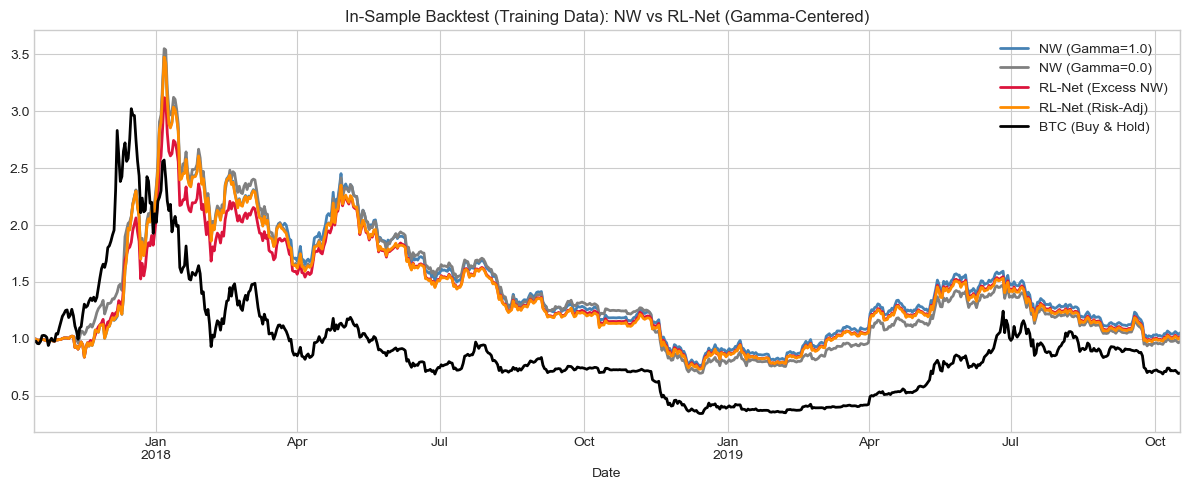

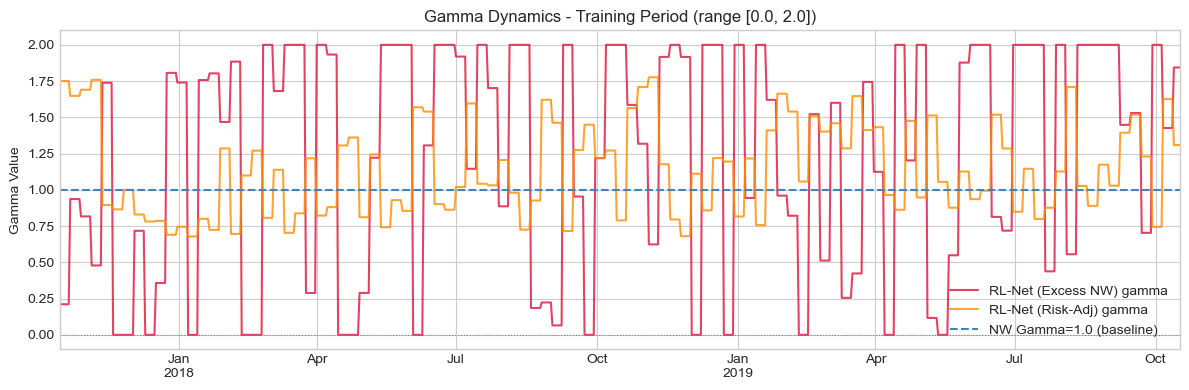

=== In-Sample Performance Metrics (Training Data) ===
                    Total Return  Ann. Return  Ann. Volatility  Sharpe Ratio  Max Drawdown
Strategy                                                                                  
NW (Gamma=1.0)          0.053621     0.018119         0.530760      0.034139     -0.780169
NW (Gamma=0.0)         -0.021746    -0.007530         0.501716     -0.015009     -0.802736
RL-Net (Excess NW)      0.021320     0.007279         0.513035      0.014188     -0.761475
RL-Net (Risk-Adj)       0.012514     0.004285         0.530550      0.008076     -0.788452
BTC (Buy & Hold)       -0.298392    -0.114704         0.684208     -0.167645     -0.885453

CSV saved to: backtest_results/


In [18]:
# ============================================================
# Phase 6: In-Sample Backtest on Training Data
# ============================================================
# Bandingkan: NW baseline vs RL-improved (gamma centered on 1.0)

strategies_insample = [
    NetworkMarkowitz('NW (Gamma=1.0)', gamma=1.0),
    NetworkMarkowitz('NW (Gamma=0.0)', gamma=0.0),
    RLNetworkMarkowitz('RL-Net (Excess NW)',     'ppo_nw_excess_v2',
                       gamma_center=GAMMA_CENTER, gamma_range=GAMMA_RANGE),
    RLNetworkMarkowitz('RL-Net (Risk-Adj)',      'ppo_nw_riskadj_v2',
                       gamma_center=GAMMA_CENTER, gamma_range=GAMMA_RANGE),
]

results_map_train = {}
gamma_map_train   = {}
for s in strategies_insample:
    res, _, g_hist = run_backtest_with_frequency(
        s, ret_old, window=SET_WINDOW, rebalance_freq=SET_REBALANCE
    )
    results_map_train[s.name] = res
    if 'RL-Net' in s.name:
        gamma_map_train[s.name] = g_hist

# Add BTC benchmark
if 'BTC' in ret_old.columns:
    results_map_train['BTC (Buy & Hold)'] = ret_old['BTC'].iloc[SET_WINDOW:]

# === Plot 1: Cumulative Returns (Training) ===
colors = {
    'NW (Gamma=1.0)':       'steelblue',
    'NW (Gamma=0.0)':       'gray',
    'RL-Net (Excess NW)':    'crimson',
    'RL-Net (Risk-Adj)':     'darkorange',
    'BTC (Buy & Hold)':     'black',
}
plt.figure(figsize=(12, 5))
for name, r in results_map_train.items():
    (1 + r).cumprod().plot(
        label=name,
        color=colors.get(name),
        linewidth=2.0
    )
plt.title('In-Sample Backtest (Training Data): NW vs RL-Net (Gamma-Centered)')
plt.legend()
plt.tight_layout()
plt.show()

# === Plot 2: Gamma Dynamics RL (Training) ===
if gamma_map_train:
    plt.figure(figsize=(12, 4))
    for name, g in gamma_map_train.items():
        g.plot(label=f'{name} gamma', color=colors.get(name), alpha=0.8)
    plt.axhline(1.0, color='steelblue', linestyle='--', label='NW Gamma=1.0 (baseline)')
    plt.axhline(0.0, color='gray', linestyle=':', linewidth=0.8)
    plt.title(f'Gamma Dynamics - Training Period (range [{GAMMA_CENTER-GAMMA_RANGE}, {GAMMA_CENTER+GAMMA_RANGE}])')
    plt.ylabel('Gamma Value')
    plt.legend()
    plt.tight_layout()
    plt.show()

# === Simpan Data Training ke CSV ===
csv_dir = 'backtest_results'
os.makedirs(csv_dir, exist_ok=True)

cumret_train_df = pd.DataFrame({name: (1 + r).cumprod() for name, r in results_map_train.items()})
cumret_train_df.index.name = 'Date'
cumret_train_df.to_csv(os.path.join(csv_dir, 'training_cumulative_returns.csv'))

dailyret_train_df = pd.DataFrame(results_map_train)
dailyret_train_df.index.name = 'Date'
dailyret_train_df.to_csv(os.path.join(csv_dir, 'training_daily_returns.csv'))

if gamma_map_train:
    gamma_train_df = pd.DataFrame(gamma_map_train)
    gamma_train_df.index.name = 'Date'
    gamma_train_df.to_csv(os.path.join(csv_dir, 'training_gamma_dynamics.csv'))

stats_train = pd.DataFrame({name: calculate_metrics(r) for name, r in results_map_train.items()}).T
stats_train.index.name = 'Strategy'
stats_train.to_csv(os.path.join(csv_dir, 'training_performance_metrics.csv'))

print('=== In-Sample Performance Metrics (Training Data) ===')
print(stats_train.to_string())
print(f'\nCSV saved to: {csv_dir}/')

## Phase 7: Diagnostic – Weight Concentration Analysis (Training Data)
Analisis mengapa NW (Gamma=1.0) sangat stabil pada training data.
Kita periksa apakah portfolio terkonsentrasi pada aset yang harganya stabil (misal USDT/stablecoin).

Processing NW (Gamma=1.0) (Freq: 7 days)...
=== Rata-rata Bobot NW (Gamma=1.0) — Training Data ===
USDT    0.362024
BTC     0.128848
BNB     0.110506
XRP     0.080856
ETH     0.068699
XLM     0.064247
LTC     0.060825
BCH     0.047814
TRX     0.039073
EOS     0.037108


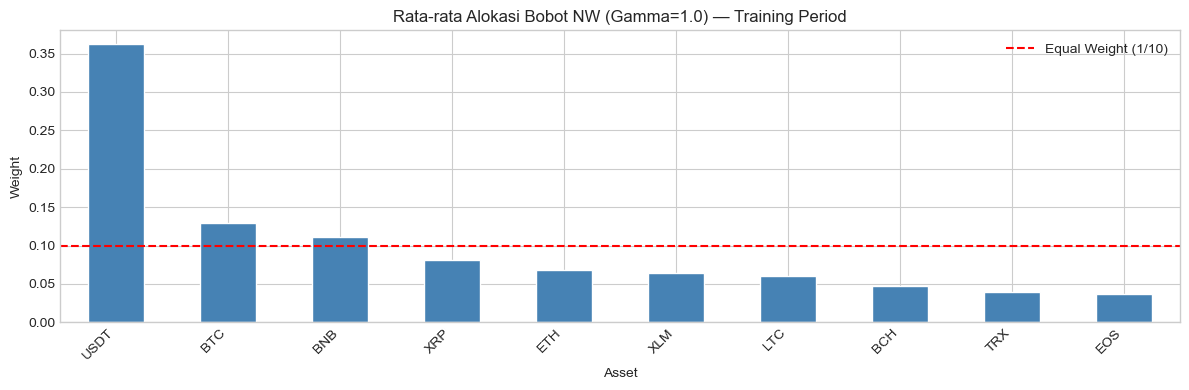

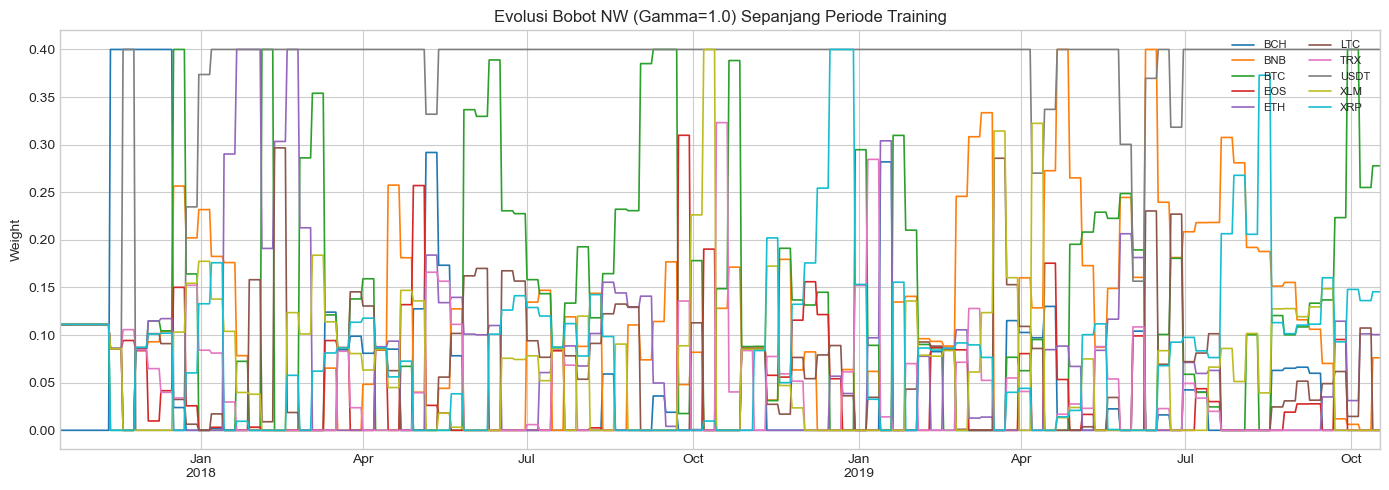


=== Jumlah Hari Bobot Aset > 30% ===
USDT    649
BTC      84
BCH      35
BNB      35
ETH      35
XLM      21
XRP      21
EOS       7
TRX       7

=== Statistik Aset vs Bobot (sorted by Volatility) ===
      Mean Daily Return  Std (Volatility)  Mean Weight
USDT          -0.000005          0.005679     0.362024
BTC            0.001236          0.043442     0.128848
ETH           -0.000772          0.050690     0.068699
LTC            0.000364          0.058470     0.060825
BNB            0.002927          0.062061     0.110506
XRP            0.000432          0.065416     0.080856
XLM            0.000629          0.065719     0.064247
EOS            0.001207          0.070927     0.037108
BCH           -0.001420          0.072359     0.047814
TRX            0.002471          0.087912     0.039073


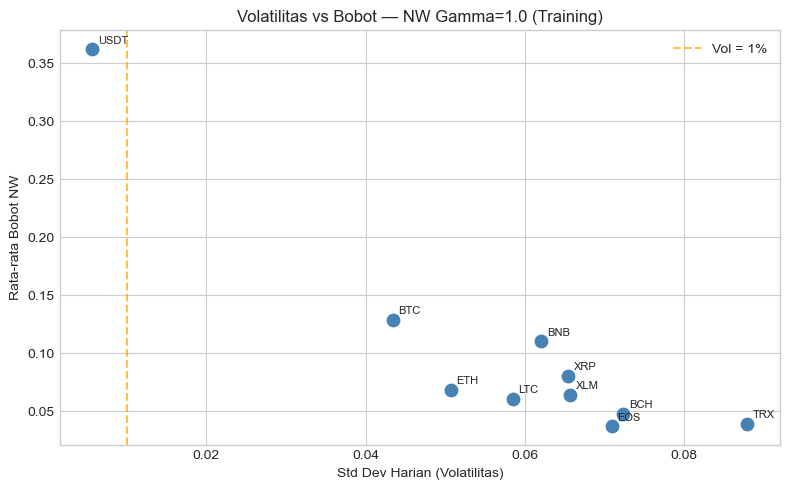


=== Korelasi Aset vs Return NW ===
ETH     0.801985
LTC     0.758417
EOS     0.745303
XLM     0.734347
BTC     0.708468
XRP     0.703818
BCH     0.687472
BNB     0.687121
TRX     0.615027
USDT    0.139305


In [19]:
# ============================================================
# Phase 7: Weight Concentration Diagnostic
# ============================================================

# Re-run backtest NW dengan menyimpan history bobot
nw_strat = NetworkMarkowitz('NW (Gamma=1.0)', gamma=1.0)
nw_ret_train, nw_wts_train, _ = run_backtest_with_frequency(
    nw_strat, ret_old, window=SET_WINDOW, rebalance_freq=SET_REBALANCE
)

# ── 1. Rata-rata bobot per aset (training period) ──────────────
mean_wts = nw_wts_train.mean().sort_values(ascending=False)
print("=== Rata-rata Bobot NW (Gamma=1.0) — Training Data ===")
print(mean_wts.to_string())

# ── 2. Bar-chart bobot rata-rata ──────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
mean_wts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Rata-rata Alokasi Bobot NW (Gamma=1.0) — Training Period")
ax.set_ylabel("Weight")
ax.set_xlabel("Asset")
ax.axhline(1/len(assets), color="red", linestyle="--", label=f"Equal Weight (1/{len(assets)})")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ── 3. Time-series bobot per aset ─────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
nw_wts_train.plot(ax=ax, linewidth=1.2)
ax.set_title("Evolusi Bobot NW (Gamma=1.0) Sepanjang Periode Training")
ax.set_ylabel("Weight")
ax.legend(loc="upper right", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

# ── 4. Deteksi asset dominan (threshold >30%) ─────────────────
dominant_threshold = 0.30
dominant_days = (nw_wts_train > dominant_threshold).sum()
print("\n=== Jumlah Hari Bobot Aset > 30% ===")
print(dominant_days[dominant_days > 0].sort_values(ascending=False).to_string())

# ── 5. Volatilitas (std) dan mean return per aset ─────────────
asset_stats = pd.DataFrame({
    "Mean Daily Return": ret_old.mean(),
    "Std (Volatility)":  ret_old.std(),
    "Mean Weight":       mean_wts,
}).sort_values("Std (Volatility)")
print("\n=== Statistik Aset vs Bobot (sorted by Volatility) ===")
print(asset_stats.round(6).to_string())

# ── 6. Scatter: volatilitas vs bobot rata-rata ────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(asset_stats["Std (Volatility)"], asset_stats["Mean Weight"], s=80, color="steelblue")
for idx, row in asset_stats.iterrows():
    ax.annotate(idx, (row["Std (Volatility)"], row["Mean Weight"]),
                textcoords="offset points", xytext=(4, 4), fontsize=8)
ax.set_xlabel("Std Dev Harian (Volatilitas)")
ax.set_ylabel("Rata-rata Bobot NW")
ax.set_title("Volatilitas vs Bobot — NW Gamma=1.0 (Training)")
ax.axvline(0.01, color="orange", linestyle="--", alpha=0.7, label="Vol = 1%")
ax.legend()
plt.tight_layout()
plt.show()

# ── 7. Korelasi aset dengan NW return ────────────────────────
corr_with_nw = ret_old.corrwith(nw_ret_train).sort_values(ascending=False)
print("\n=== Korelasi Aset vs Return NW ===")
print(corr_with_nw.to_string())


## Phase 8: Out-of-Sample Backtest (2024 Data)
Backtesting the trained RL models on the **out-of-sample 2024 period** to evaluate performance on unseen data.

Processing NW (Gamma=1.0) (Freq: 7 days)...
Processing NW (Gamma=0.0) (Freq: 7 days)...
Processing RL-Net (Excess NW) (Freq: 7 days)...
Processing RL-Net (Risk-Adj) (Freq: 7 days)...


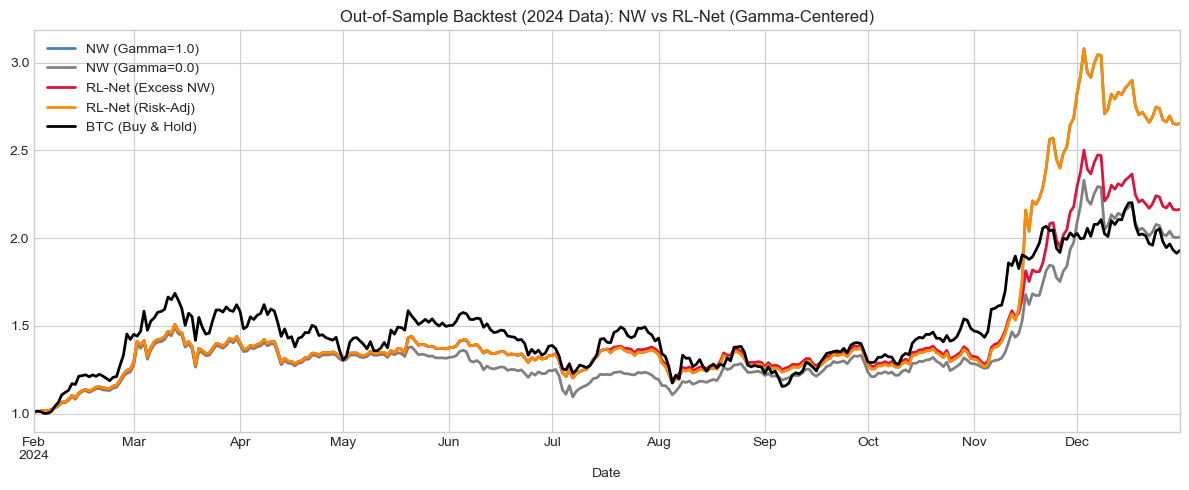

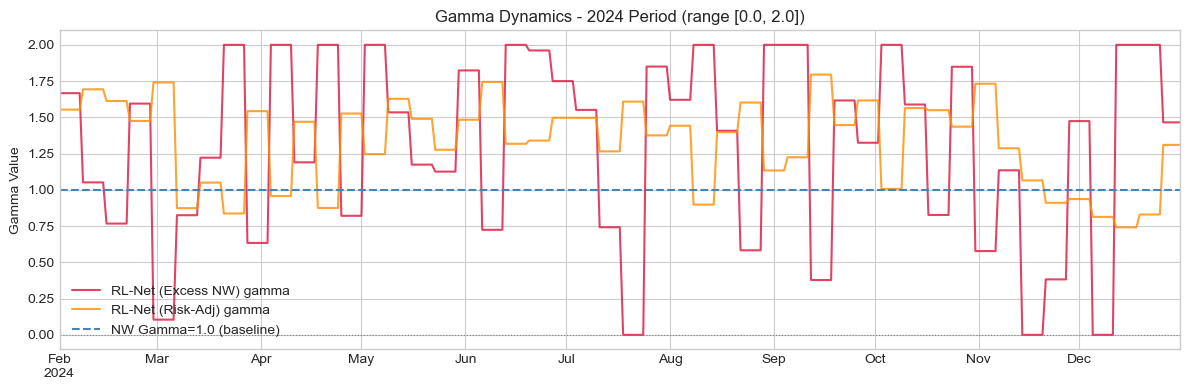

=== Out-of-Sample Performance Metrics (2024 Data) ===
                    Total Return  Ann. Return  Ann. Volatility  Sharpe Ratio  Max Drawdown
Strategy                                                                                  
NW (Gamma=1.0)          1.653507     1.083599         0.404732      2.677327     -0.220694
NW (Gamma=0.0)          1.007078     0.688887         0.337801      2.039329     -0.266438
RL-Net (Excess NW)      1.164759     0.787755         0.344153      2.288970     -0.211525
RL-Net (Risk-Adj)       1.653492     1.083590         0.404739      2.677255     -0.220690
BTC (Buy & Hold)        0.930106     0.639930         0.440520      1.452667     -0.315253

CSV saved to: backtest_results/


In [20]:
# ============================================================
# Phase 8: Out-of-Sample Backtest on 2024 Data
# ============================================================

strategies_oos = [
    NetworkMarkowitz('NW (Gamma=1.0)', gamma=1.0),
    NetworkMarkowitz('NW (Gamma=0.0)', gamma=0.0),
    RLNetworkMarkowitz('RL-Net (Excess NW)',     'ppo_nw_excess_v2',
                       gamma_center=GAMMA_CENTER, gamma_range=GAMMA_RANGE),
    RLNetworkMarkowitz('RL-Net (Risk-Adj)',      'ppo_nw_riskadj_v2',
                       gamma_center=GAMMA_CENTER, gamma_range=GAMMA_RANGE),
]

results_map_2024 = {}
gamma_map_2024   = {}
for s in strategies_oos:
    res, _, g_hist = run_backtest_with_frequency(
        s, ret_2024, window=SET_WINDOW, rebalance_freq=SET_REBALANCE
    )
    results_map_2024[s.name] = res
    if 'RL-Net' in s.name:
        gamma_map_2024[s.name] = g_hist

# Add BTC benchmark
if 'BTC' in ret_2024.columns:
    results_map_2024['BTC (Buy & Hold)'] = ret_2024['BTC'].iloc[SET_WINDOW:]

# === Plot 1: Cumulative Returns (2024) ===
colors = {
    'NW (Gamma=1.0)':       'steelblue',
    'NW (Gamma=0.0)':       'gray',
    'RL-Net (Excess NW)':    'crimson',
    'RL-Net (Risk-Adj)':     'darkorange',
    'BTC (Buy & Hold)':     'black',
}

plt.figure(figsize=(12, 5))
for name, r in results_map_2024.items():
    (1 + r).cumprod().plot(
        label=name,
        color=colors.get(name),
        linewidth=2.0
    )
plt.title('Out-of-Sample Backtest (2024 Data): NW vs RL-Net (Gamma-Centered)')
plt.legend()
plt.tight_layout()
plt.show()

# === Plot 2: Gamma Dynamics RL (2024) ===
if gamma_map_2024:
    plt.figure(figsize=(12, 4))
    for name, g in gamma_map_2024.items():
        g.plot(label=f'{name} gamma', color=colors.get(name), alpha=0.8)
    plt.axhline(1.0, color='steelblue', linestyle='--', label='NW Gamma=1.0 (baseline)')
    plt.axhline(0.0, color='gray', linestyle=':', linewidth=0.8)
    plt.title(f'Gamma Dynamics - 2024 Period (range [{GAMMA_CENTER-GAMMA_RANGE}, {GAMMA_CENTER+GAMMA_RANGE}])')
    plt.ylabel('Gamma Value')
    plt.legend()
    plt.tight_layout()
    plt.show()

# === Simpan Data OOS ke CSV ===
csv_dir = 'backtest_results'
os.makedirs(csv_dir, exist_ok=True)

cumret_2024_df = pd.DataFrame({name: (1 + r).cumprod() for name, r in results_map_2024.items()})
cumret_2024_df.index.name = 'Date'
cumret_2024_df.to_csv(os.path.join(csv_dir, '2024_cumulative_returns.csv'))

dailyret_2024_df = pd.DataFrame(results_map_2024)
dailyret_2024_df.index.name = 'Date'
dailyret_2024_df.to_csv(os.path.join(csv_dir, '2024_daily_returns.csv'))

if gamma_map_2024:
    gamma_2024_df = pd.DataFrame(gamma_map_2024)
    gamma_2024_df.index.name = 'Date'
    gamma_2024_df.to_csv(os.path.join(csv_dir, '2024_gamma_dynamics.csv'))

stats_2024 = pd.DataFrame({name: calculate_metrics(r) for name, r in results_map_2024.items()}).T
stats_2024.index.name = 'Strategy'
stats_2024.to_csv(os.path.join(csv_dir, '2024_performance_metrics.csv'))

print('=== Out-of-Sample Performance Metrics (2024 Data) ===')
print(stats_2024.to_string())
print(f'\nCSV saved to: {csv_dir}/')